# <span style="color:#e0bda8">1. Import Packages and Libraries</span>

In [1]:
# 1. Data Manipulation
# =====================================================
import pandas as pd
import numpy as np


# 2. Model Selection & Validation
# =====================================================
from sklearn.model_selection import train_test_split, GridSearchCV


# 3. Pipeline Construction
# =====================================================
from sklearn.pipeline import Pipeline


# 4. Model Evaluation
# =====================================================
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)


# 5. Machine Learning Model
# =====================================================
from xgboost import XGBRegressor


# 6. Model Explainability
# =====================================================
import shap


# 7. Data Visualization
# =====================================================
import matplotlib.pyplot as plt


# 8. Path Configuration
# =====================================================
import os
import joblib


# 9. Utilities
# =====================================================
import warnings

warnings.filterwarnings('ignore')


# <span style="color:#e0bda8">2. Project Structure and Directory Configuration </span>   

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(PROJECT_ROOT, "01_Data")
DATA_RAW = os.path.join(DATA, "01_Raw")
DATA_PROCESSED = os.path.join(DATA, "02_Processed")
DATA_STATS = os.path.join(DATA, "03_Statistics")
DATA_INDEX = os.path.join(DATA, "04_Index_Final")

CLUSTER_PCA = os.path.join(PROJECT_ROOT, "03_Clustering_PCA")
CLUSTER_PCA_EXCEL = os.path.join(CLUSTER_PCA, "01_Excel")
CLUSTER_PCA_FIG = os.path.join(CLUSTER_PCA, "02_Figures")

METHOD = os.path.join(PROJECT_ROOT, "04_Method_Comparison")
METHOD_EXCEL = os.path.join(METHOD, "01_Excel")
METHOD_FIG = os.path.join(METHOD, "02_Figures")

ML_RESULTS = os.path.join(PROJECT_ROOT, "05_ML_Results")
ML_METRICS = os.path.join(ML_RESULTS, "01_Metrics")
ML_PRED = os.path.join(ML_RESULTS, "02_Predictions")
ML_MODELS = os.path.join(ML_RESULTS, "03_Models")
ML_SHAP = os.path.join(ML_RESULTS, "04_SHAP")
ML_SHAP_EXCEL = os.path.join(ML_SHAP, "01_Excel")
ML_SHAP_FIG = os.path.join(ML_SHAP, "02_Figures")


# <span style="color:#e0bda8">3. Reading the Data</span>

In [3]:
df_env_ml = pd.read_csv(os.path.join(DATA_INDEX, 'df_env_ml.csv')) 
df_env_ml = df_env_ml.set_index(['Economy', 'Year'])

df_soc_ml = pd.read_csv(os.path.join(DATA_INDEX, 'df_soc_ml.csv')) 
df_soc_ml = df_soc_ml.set_index(['Economy', 'Year'])

df_gov_ml = pd.read_csv(os.path.join(DATA_INDEX, 'df_gov_ml.csv')) 
df_gov_ml = df_gov_ml.set_index(['Economy', 'Year'])

cpi_csv = pd.read_csv(os.path.join(DATA_RAW, 'cpi.csv')) 

# <span style="color:#e0bda8">4. Including CPI in the ESG Dataframes </span>

In [4]:
cpi_csv.head(5)

,Unnamed: 0,Corruption Perceptions Index 2020: Score timeseries since 2012,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,...,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Country,ISO3,Region,CPI score 2020,Rank 2020,Sources 2020,Standard error 2020,CPI score 2019,Rank 2019,...,Standard error 2015,CPI score 2014,Sources 2014,Standard error 2014,CPI Score 2013,Sources 2013,Standard error 2013,CPI Score 2012,Sources 2012,Standard error 2012
2,2,Denmark,DNK,WE/EU,88,1,8,1.775809,87,1,...,2.16,92,7,2.04,91,7,2.2,90,7,2
3,3,New Zealand,NZL,AP,88,1,8,1.479342,87,1,...,2.32,91,7,2.28,91,7,2.3,90,7,2.2
4,4,Finland,FIN,WE/EU,85,3,8,1.748594,86,3,...,1.77,89,7,2.05,89,7,1.7,90,7,3


In [5]:
cpi = cpi_csv.iloc[1:, 1:]
cpi.columns = cpi.iloc[0]
cpi = cpi.iloc[1:]
cpi.columns.name = None
cpi.columns = cpi.columns.str.replace('CPI score', '', regex=False).str.strip()
cpi.columns = cpi.columns.str.replace('CPI Score', '', regex=False).str.strip()
cpi.columns = cpi.columns.str.replace('Country', 'Economy', regex=False).str.strip()

In [6]:
cols_years = [str(year) for year in range(2012, 2021)]

cpi_long = cpi.melt(
    id_vars=['Economy'],
    value_vars=cols_years,      
    var_name='Year',          
    value_name='CPI'        
)

cpi_long['Year'] = cpi_long['Year'].astype('int64')

cpi_long = cpi_long.set_index(['Economy', 'Year'])

europe_countries = ["Albania", "Armenia", "Austria", "Azerbaijan", "Belarus", "Belgium", "Bosnia and Herzegovina", 
                    "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark", "Estonia", "Finland", "France", 
                    "Georgia", "Germany", "Greece", "Hungary", "Iceland", "Ireland", "Italy", "Kazakhstan", 
                    "Latvia", "Lithuania", "Luxembourg", "Malta", "Moldova", "Montenegro", "Netherlands", 
                    "North Macedonia", "Norway", "Poland", "Portugal", "Romania", "Russia", "Serbia", 
                    "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Turkey", "Ukraine", "United Kingdom"]

cpi_europe = cpi_long[cpi_long.index.get_level_values('Economy').isin(europe_countries)] 
cpi_europe['CPI'] = cpi_europe['CPI'].astype('int64')

cpi_europe = cpi_europe.rename(
    index={
        'Slovakia': 'Slovak Republic',
        'Russia': 'Russian Federation',
        'Turkey': 'Turkiye'
    },
    level='Economy'
)

cpi_europe = cpi_europe.sort_index()

In [7]:
df_env_cpi = df_env_ml.copy()
df_env_cpi = df_env_cpi.sort_index()
df_env_cpi['CPI'] = cpi_europe['CPI']

df_soc_cpi = df_soc_ml.copy()
df_soc_cpi = df_soc_cpi.sort_index()
df_soc_cpi['CPI'] = cpi_europe['CPI']

df_gov_cpi = df_gov_ml.copy()
df_gov_cpi = df_gov_cpi.sort_index()
df_gov_cpi['CPI'] = cpi_europe['CPI']

In [8]:
df_env_cpi.head(5)


PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)  \
Economy Year                                                                           
Albania 2012                                          34.781333                        
        2013                                          38.423238                        
        2014                                          38.519555                        
        2015                                          39.122858                        
        2016                                          43.016221                        

              Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)  \
Economy Year                                                                      
Albania 2012                                          87.305664                   
        2013                                          86.680682                   
        2014                                          85.858362                   
        2015                                          86.438749                   
        2016                                          87.312685                   

              Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  \
Economy Year                                                                               
Albania 2012                                         100.000000                            
        2013                                          99.553040                            
        2014                                          98.937346                            
        2015                                          99.336701                            
        2016                                          99.934940                            

              Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e)  \
Economy Year                                                                                               
Albania 2012                                          17.003573                                            
        2013                                          26.858845                                            
        2014                                          27.379557                                            
        2015                                          27.171973                                            
        2016                                          26.855894                                            

              Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e)  \
Economy Year                                                               
Albania 2012                                          80.645069            
        2013                                          80.306174            
        2014                                          79.989850            
        2015                                          79.805421            
        2016                                          80.023723            

              Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e)  \
Economy Year                                                                     
Albania 2012                                          85.553923                  
        2013                                          86.142505                  
        2014                                          85.277106                  
        2015                                          85.018972                  
        2016                                          85.182366                  

              Total greenhouse gas emissions excluding LULUCF (Mt CO2e)  \
Economy Year                                                              
Albania 2012                                          82.351112           
        2013                                          81.931741           
     

# <span style="color:#e0bda8">5. Model Training and Evaluation </span>

### <span style="color:#e0bda8">5.0. Auxiliary Functions </span>

In [9]:
def train_xgb_pipeline(df, target_col='Score', test_size=0.2, random_state=42, cv=5, pillar_png=None):
    """Treina XGBoost com GridSearchCV, retorna métricas e objetos para SHAP.
    Requer features numéricas e pré-processadas (scaling/fill NA já feito).

    Comportamento adicional:
    - Se o DataFrame tiver índice nomeado ou MultiIndex, o índice será convertido em colunas.
    - Colunas identificadoras como `economy`, `Economy`, `year`, `Year`, `country` serão
      descartadas automaticamente antes do treino.
    - Se existirem outras colunas não-numéricas, a função levanta um erro mostrando exemplos.
    """
    original_index = df.index.copy()

    # -- normalizar índice: reset quando o índice não for RangeIndex ou for MultiIndex
    if isinstance(df.index, pd.MultiIndex) or any(name is not None for name in (df.index.names or [])):
        df = df.reset_index()

    # separa X/y
    if target_col not in df.columns:
        raise ValueError(f"Coluna alvo '{target_col}' não encontrada no DataFrame.")
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].astype(float)

    # detectar e remover colunas identificadoras (case-insensitive)
    id_cols = [c for c in X.columns if c.lower() in ('economy', 'year', 'country', 'index')]
    if id_cols:
        print(f"Removendo colunas identificadoras: {id_cols}")
        X = X.drop(columns=id_cols)

    # checar colunas não-numéricas restantes
    non_numeric = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
    if non_numeric:
        # Se todas as colunas não-numéricas forem apenas identificadores, já teríamos removido acima.
        sample_vals = {c: X[c].dropna().unique()[:5].tolist() for c in non_numeric}
        raise ValueError(f"Colunas previsoras não-numéricas encontradas: {non_numeric}. Exemplos de valores: {sample_vals}")

    # treino / validação
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    X_test.index = original_index[X_test.index]
    y_test.index = original_index[y_test.index]

    pipe = Pipeline([('model', XGBRegressor(objective='reg:squarederror', random_state=random_state, n_jobs=-1))])

    param_grid = {
        'model__n_estimators': [100, 300],
        'model__max_depth': [3, 6],
        'model__learning_rate': [0.01, 0.1],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0],
        'model__reg_alpha': [0, 0.1],
        'model__reg_lambda': [1, 5]
    }

    grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='neg_mean_squared_error',
                        n_jobs=-1, verbose=2, return_train_score=True)
    
    grid.fit(X_train, y_train)

    best = grid.best_estimator_
    y_pred = best.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("Best params:", grid.best_params_)
    print(f"Test RMSE: {rmse:.4f}   |   MAE: {mae:.4f}   |   R2: {r2:.4f}")

    cvres = pd.DataFrame(grid.cv_results_)
    cvres['rmse'] = np.sqrt(-cvres['mean_test_score'])
    display(cvres.sort_values('rank_test_score')[['params','rmse','mean_train_score','std_test_score']].head(10))

    explainer = shap.TreeExplainer(best.named_steps['model'])
    shap_values = explainer.shap_values(X_test)

    shap_importance = pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)

    shap_importance.to_csv(os.path.join(ML_SHAP_EXCEL, f'{pillar_png}_shap_importance.csv'))

    return {
        'grid': grid,
        'best_estimator': best,
        'metrics': {'rmse': rmse, 'mae': mae, 'r2': r2},
        'X_test': X_test, 'y_test': y_test, 'y_pred': y_pred, 
        'test_index': y_test.index,
        'shap_values': shap_values, 'explainer': explainer
    }

In [10]:
def show_actual_vs_pred(results, pillar_png=None, pillar_title=None):
    y_test = results['y_test']
    y_pred = pd.Series(results['y_pred'], index=y_test.index)

    pred_df = pd.DataFrame({
        'actual': y_test,
        'predicted': y_pred
    })

    pred_df['error'] = pred_df['predicted'] - pred_df['actual']
    pred_df['abs_error'] = pred_df['error'].abs()

    print('\nLowest absolute errors:')
    display(pred_df.sort_values('abs_error', ascending=True).head(10))

    print('\nHighest absolute errors:')
    display(pred_df.sort_values('abs_error', ascending=False).head(10))

    # scatter actual vs predicted
    plt.figure(figsize=(6,6))
    plt.scatter(pred_df['actual'],pred_df['predicted'], alpha=0.6)
    mn = min(pred_df['actual'].min(), pred_df['predicted'].min())
    mx = max(pred_df['actual'].max(), pred_df['predicted'].max())
    plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
    plt.xlabel('actual')
    plt.ylabel('predicted')
    plt.title(f'{pillar_title} scores: actual vs predicted')
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(ML_SHAP_FIG, f'{pillar_png} actual vs predicted scores.png'), dpi=300, bbox_inches="tight")
    plt.show()

    pred_df = pred_df.sort_index()
    pred_df.to_csv(os.path.join(ML_PRED, f"{pillar_png}_predictions.csv"))
    
    

    return pred_df 

## <span style="color:#e0bda8">5.1. Environmental Pillar </span>

In [11]:
env_model = train_xgb_pipeline(df_env_cpi, target_col='Score', test_size=0.2, random_state=42, cv=5, pillar_png='env')

Removendo colunas identificadoras: ['Economy', 'Year']
Fitting 5 folds for each of 128 candidates, totalling 640 fits
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0, 'model__reg_lambda': 1, 'model__subsample': 0.8}
Test RMSE: 0.9484   |   MAE: 0.7381   |   R2: 0.9837


,params,rmse,mean_train_score,std_test_score
40,"{'model__colsample_bytree': 0.8, 'model__learn...",0.968051,-0.004146,0.179055
104,"{'model__colsample_bytree': 1.0, 'model__learn...",0.977946,-0.003560,0.232378
106,"{'model__colsample_bytree': 1.0, 'model__learn...",0.981436,-0.010463,0.248943
44,"{'model__colsample_bytree': 0.8, 'model__learn...",0.989096,-0.005068,0.153340
46,"{'model__colsample_bytree': 0.8, 'model__learn...",0.991768,-0.012850,0.214713
110,"{'model__colsample_bytree': 1.0, 'model__learn...",0.992420,-0.011606,0.203907
108,"{'model__colsample_bytree': 1.0, 'model__learn...",1.006898,-0.004255,0.213112
42,"{'model__colsample_bytree': 0.8, 'model__learn...",1.009676,-0.011256,0.233615
107,"{'model__colsample_bytree': 1.0, 'model__learn...",1.039123,-0.012152,0.234507
111,"{'model__colsample_bytree': 1.0, 'model__learn...",1.042380,-0.012137,0.225771


In [12]:
joblib.dump(env_model, os.path.join(ML_MODELS, "env_model.pkl"))

['c:\\Users\\pedro\\OneDrive\\Tese\\05_ML_Results\\03_Models\\env_model.pkl']


Lowest absolute errors:


,,actual,predicted,error,abs_error
Economy,Year,,,,
Croatia,2016,58.561823,58.561451,-0.000372,0.000372
Italy,2015,46.243989,46.271114,0.027126,0.027126
Serbia,2012,44.935796,44.898438,-0.037359,0.037359
Iceland,2014,69.416010,69.347511,-0.068499,0.068499
Ireland,2012,47.757278,47.837418,0.080139,0.080139
Hungary,2018,46.592893,46.501381,-0.091513,0.091513
Slovak Republic,2016,56.365419,56.490326,0.124907,0.124907
Ukraine,2018,37.717636,37.591873,-0.125763,0.125763
Greece,2014,44.959217,45.090496,0.131279,0.131279



Highest absolute errors:


,,actual,predicted,error,abs_error
Economy,Year,,,,
Croatia,2012,52.601982,55.134499,2.532517,2.532517
Slovenia,2012,57.350566,54.868565,-2.482001,2.482001
Greece,2012,44.685752,46.966236,2.280484,2.280484
Denmark,2014,52.918871,55.014915,2.096044,2.096044
Ukraine,2012,35.739855,37.800041,2.060186,2.060186
Turkiye,2019,44.343935,46.014874,1.670938,1.670938
Montenegro,2013,61.909227,60.254467,-1.654759,1.654759
Sweden,2017,67.217294,65.656082,-1.561212,1.561212
Bulgaria,2019,50.264724,48.739189,-1.525535,1.525535


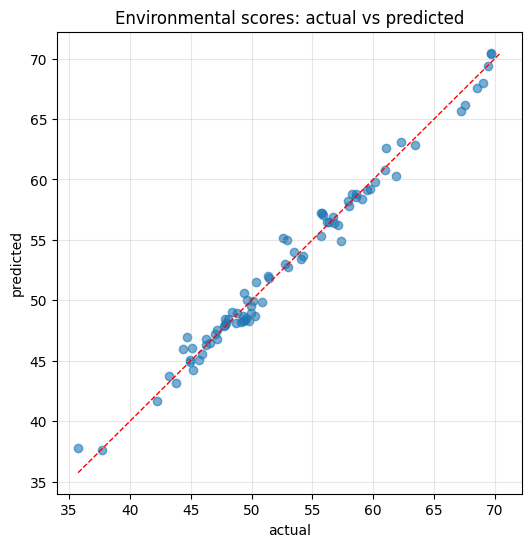

In [13]:
df_env_predictions = show_actual_vs_pred(env_model, pillar_png='env', pillar_title='Environmental')

## <span style="color:#e0bda8">5.2. Social Pillar </span>

In [14]:
soc_model = train_xgb_pipeline(df_soc_cpi, target_col='Score', test_size=0.2, random_state=42, cv=5, pillar_png='soc')

Removendo colunas identificadoras: ['Economy', 'Year']
Fitting 5 folds for each of 128 candidates, totalling 640 fits
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0, 'model__reg_lambda': 1, 'model__subsample': 0.8}
Test RMSE: 0.9658   |   MAE: 0.7054   |   R2: 0.9961


,params,rmse,mean_train_score,std_test_score
40,"{'model__colsample_bytree': 0.8, 'model__learn...",1.315040,-0.010558,0.600407
106,"{'model__colsample_bytree': 1.0, 'model__learn...",1.316738,-0.022385,0.862275
44,"{'model__colsample_bytree': 0.8, 'model__learn...",1.319415,-0.011602,0.601687
56,"{'model__colsample_bytree': 0.8, 'model__learn...",1.352008,-0.000003,0.713406
110,"{'model__colsample_bytree': 1.0, 'model__learn...",1.356136,-0.023981,0.928675
109,"{'model__colsample_bytree': 1.0, 'model__learn...",1.356815,-0.012002,0.776703
60,"{'model__colsample_bytree': 0.8, 'model__learn...",1.357768,-0.000147,0.770884
105,"{'model__colsample_bytree': 1.0, 'model__learn...",1.358787,-0.015162,0.797300
45,"{'model__colsample_bytree': 0.8, 'model__learn...",1.362141,-0.014146,0.754560
48,"{'model__colsample_bytree': 0.8, 'model__learn...",1.362987,-0.005487,0.722905


In [15]:
joblib.dump(soc_model, os.path.join(ML_MODELS, "soc_model.pkl"))

['c:\\Users\\pedro\\OneDrive\\Tese\\05_ML_Results\\03_Models\\soc_model.pkl']


Lowest absolute errors:


,,actual,predicted,error,abs_error
Economy,Year,,,,
Finland,2019,80.389591,80.383980,-0.005612,0.005612
Azerbaijan,2015,39.935758,39.903740,-0.032018,0.032018
Portugal,2012,61.702832,61.736404,0.033573,0.033573
Sweden,2017,79.006996,78.968445,-0.038551,0.038551
Malta,2017,74.741809,74.700500,-0.041308,0.041308
Czechia,2016,79.153125,79.204948,0.051823,0.051823
Croatia,2012,57.295520,57.229313,-0.066207,0.066207
Turkiye,2015,38.868967,38.802559,-0.066409,0.066409
Ukraine,2012,62.196491,62.114777,-0.081714,0.081714



Highest absolute errors:


actual  predicted     error  abs_error
Economy  Year                                           
Slovenia 2012  73.863679  70.765511 -3.098168   3.098168
Albania  2012  38.209488  35.541882 -2.667606   2.667606
Croatia  2017  62.262433  64.712524  2.450092   2.450092
Moldova  2018  51.616930  49.382797 -2.234133   2.234133
         2019  51.931941  50.000671 -1.931270   1.931270
Estonia  2018  72.475783  74.336929  1.861147   1.861147
Bulgaria 2019  58.729754  56.895477 -1.834277   1.834277
Greece   2012  58.382416  60.115883  1.733467   1.733467
Croatia  2016  61.182686  62.824139  1.641453   1.641453
Iceland  2014  79.697875  78.135612 -1.562262   1.562262

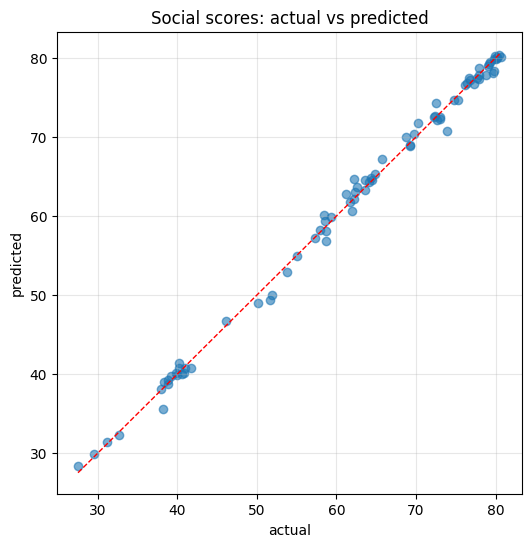

In [16]:
df_soc_predictions = show_actual_vs_pred(soc_model, pillar_png='soc', pillar_title='Social')

## <span style="color:#e0bda8">5.3. Governance Pillar </span>

In [17]:
gov_model = train_xgb_pipeline(df_gov_cpi, target_col='Score', test_size=0.2, random_state=42, cv=5, pillar_png='gov')

Removendo colunas identificadoras: ['Economy', 'Year']
Fitting 5 folds for each of 128 candidates, totalling 640 fits
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__reg_alpha': 0, 'model__reg_lambda': 5, 'model__subsample': 0.8}
Test RMSE: 0.9655   |   MAE: 0.7479   |   R2: 0.9973


,params,rmse,mean_train_score,std_test_score
42,"{'model__colsample_bytree': 0.8, 'model__learn...",1.378088,-0.033823,0.344118
46,"{'model__colsample_bytree': 0.8, 'model__learn...",1.382758,-0.036256,0.339950
40,"{'model__colsample_bytree': 0.8, 'model__learn...",1.477180,-0.014474,0.371746
104,"{'model__colsample_bytree': 1.0, 'model__learn...",1.506744,-0.014036,0.616049
44,"{'model__colsample_bytree': 0.8, 'model__learn...",1.516094,-0.015502,0.410296
108,"{'model__colsample_bytree': 1.0, 'model__learn...",1.519493,-0.014260,0.663466
34,"{'model__colsample_bytree': 0.8, 'model__learn...",1.533398,-0.340567,0.412715
38,"{'model__colsample_bytree': 0.8, 'model__learn...",1.536594,-0.343776,0.381833
110,"{'model__colsample_bytree': 1.0, 'model__learn...",1.584432,-0.031677,0.696522
106,"{'model__colsample_bytree': 1.0, 'model__learn...",1.584938,-0.028661,0.735518


In [18]:
joblib.dump(gov_model, os.path.join(ML_MODELS, "gov_model.pkl"))

['c:\\Users\\pedro\\OneDrive\\Tese\\05_ML_Results\\03_Models\\gov_model.pkl']


Lowest absolute errors:


,,actual,predicted,error,abs_error
Economy,Year,,,,
Netherlands,2016,80.976794,80.966034,-0.010761,0.010761
Moldova,2018,26.962547,26.979609,0.017061,0.017061
Sweden,2016,84.177418,84.230225,0.052807,0.052807
Georgia,2017,40.091839,40.030617,-0.061223,0.061223
Belarus,2018,38.424565,38.507545,0.082980,0.082980
Russian Federation,2014,36.099917,36.194366,0.094450,0.094450
Bosnia and Herzegovina,2015,31.982192,31.885395,-0.096797,0.096797
France,2012,75.277928,75.177498,-0.100430,0.100430
Sweden,2017,85.394559,85.259216,-0.135343,0.135343



Highest absolute errors:


actual  predicted     error  abs_error
Economy         Year                                           
Croatia         2016  46.633135  50.240395  3.607259   3.607259
Slovak Republic 2015  54.373935  57.229530  2.855595   2.855595
Croatia         2012  47.497352  45.690430 -1.806922   1.806922
Estonia         2020  65.893004  67.680984  1.787981   1.787981
Czechia         2016  62.930740  64.646233  1.715493   1.715493
Belgium         2013  73.584483  72.008896 -1.575587   1.575587
                2012  72.856819  71.301971 -1.554847   1.554847
Turkiye         2015  42.564350  41.128788 -1.435562   1.435562
Albania         2017  37.439860  38.858910  1.419050   1.419050
Armenia         2012  29.635323  30.989693  1.354370   1.354370

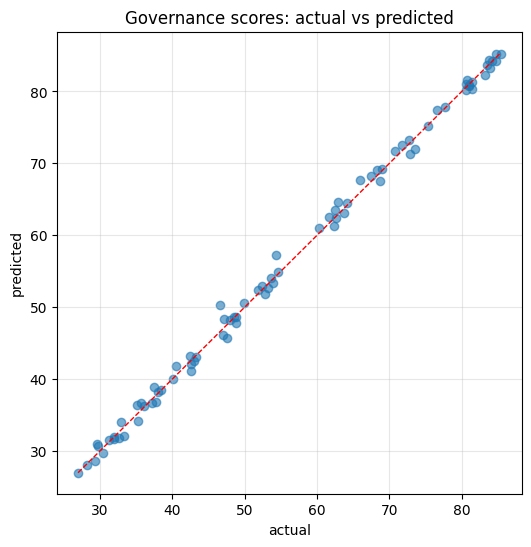

In [19]:
df_gov_predictions = show_actual_vs_pred(gov_model, pillar_png='gov', pillar_title='Governance')

## <span style="color:#e0bda8">5.4. Metrics Table </span>

In [20]:
metrics_df = pd.DataFrame({
    'Environmental': env_model['metrics'],
    'Social': soc_model['metrics'],
    'Governance': gov_model['metrics']
}).T

metrics_df

,rmse,mae,r2
Environmental,0.948406,0.738091,0.983715
Social,0.965805,0.705365,0.996131
Governance,0.965504,0.747945,0.997251


In [21]:
metrics_df.to_excel(os.path.join(ML_METRICS, "ml_metrics.xlsx"))

# <span style="color:#e0bda8">6. SHAP Visualizations </span>

### <span style="color:#e0bda8">6.0. Auxiliary Functions </span>

In [22]:
def plot_shap(shap_values, X_test, pillar_png=None, pillar_title=None):
    # BAR PLOT
    shap.summary_plot(
        shap_values, 
        X_test, 
        plot_type="bar", 
        max_display=40, 
        show=False
    )
    fig = plt.gcf()
    fig.set_size_inches(16, 8)
    plt.title(f"SHAP Feature Importance - {pillar_title}", fontsize=16)
    plt.tight_layout()

    plt.savefig(
    os.path.join(ML_SHAP_FIG, f'{pillar_png}_shap_barplot.png'),
    dpi=300,
    bbox_inches="tight"
    )

    plt.show()

    # BEESWARM
    shap.summary_plot(
        shap_values, 
        X_test, 
        max_display=40, 
        show=False
    )
    fig = plt.gcf()
    fig.set_size_inches(16, 8)
    plt.title(f"SHAP Beeswarm - {pillar_title}", fontsize=16)
    plt.tight_layout()

    plt.savefig(
    os.path.join(ML_SHAP_FIG, f'{pillar_png}_shap_beeswarm.png'),
    dpi=300,
    bbox_inches="tight"
    )

    plt.show()



## <span style="color:#e0bda8">6.1. Environmental Pillar </span>

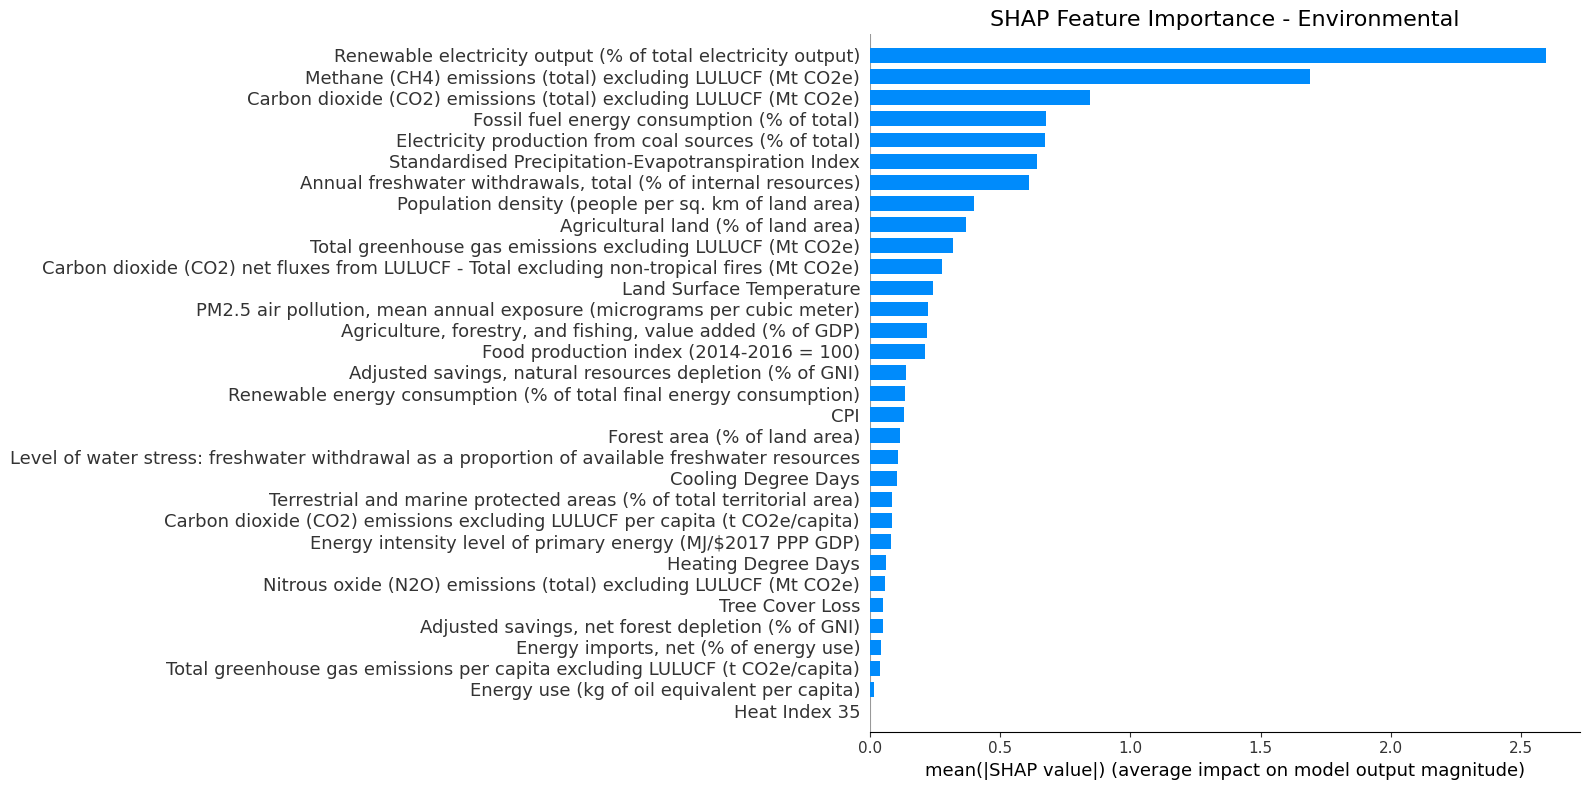

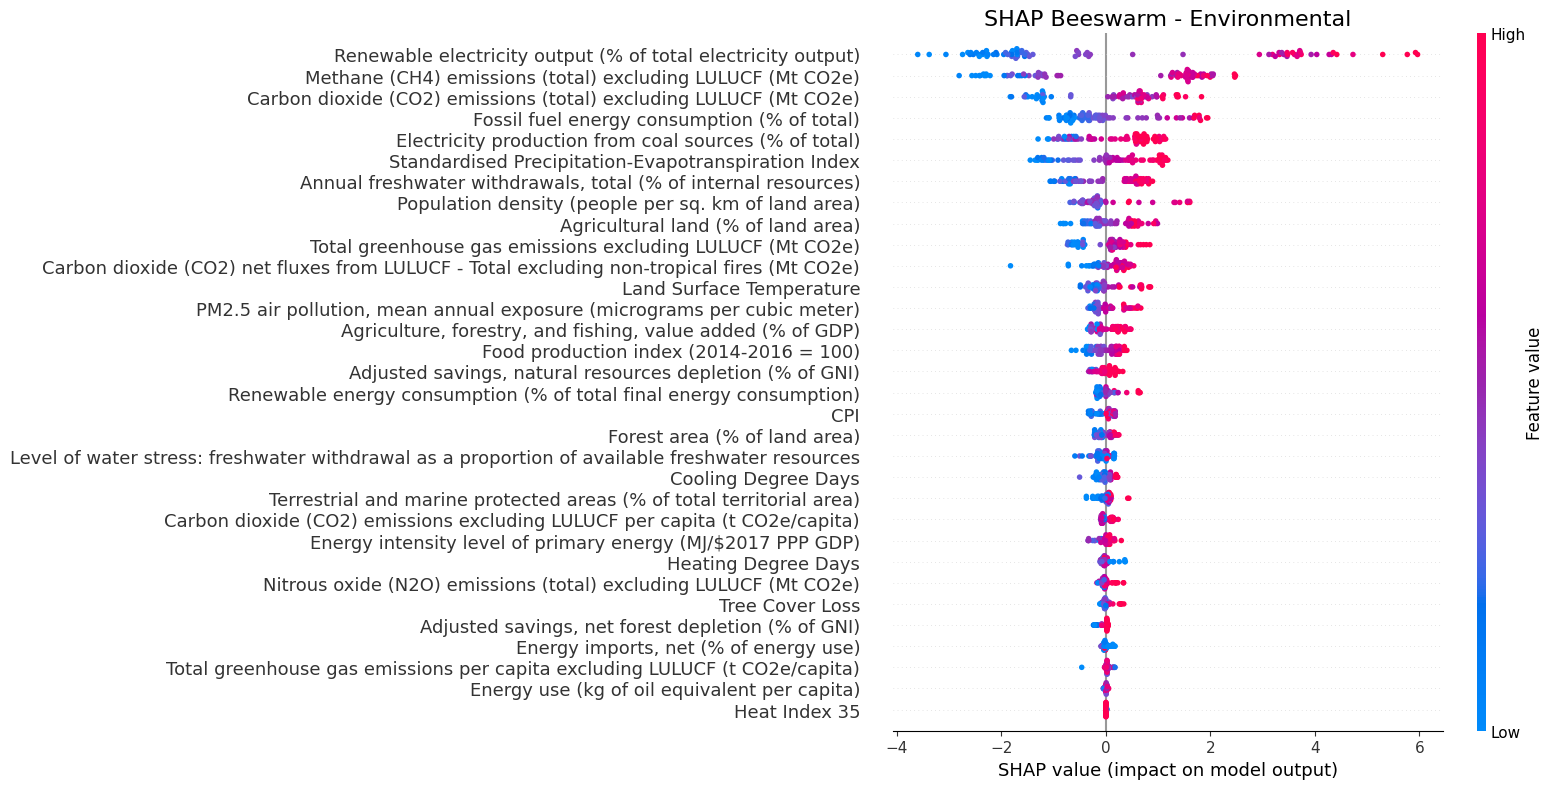

In [23]:
plot_shap(env_model['shap_values'], env_model['X_test'], pillar_png='env', pillar_title='Environmental')

## <span style="color:#e0bda8">6.2. Social Pillar </span>

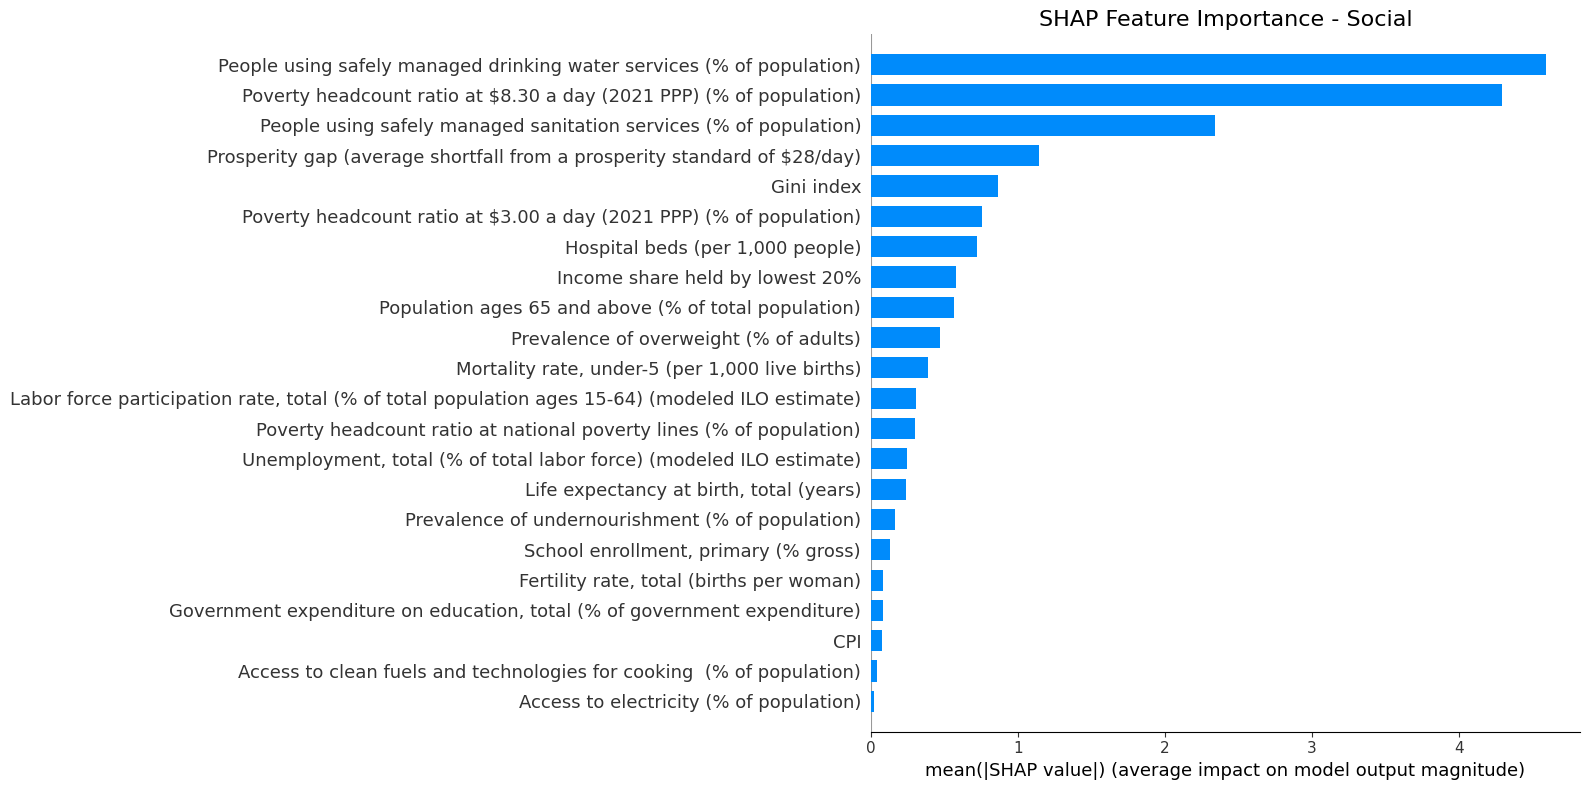

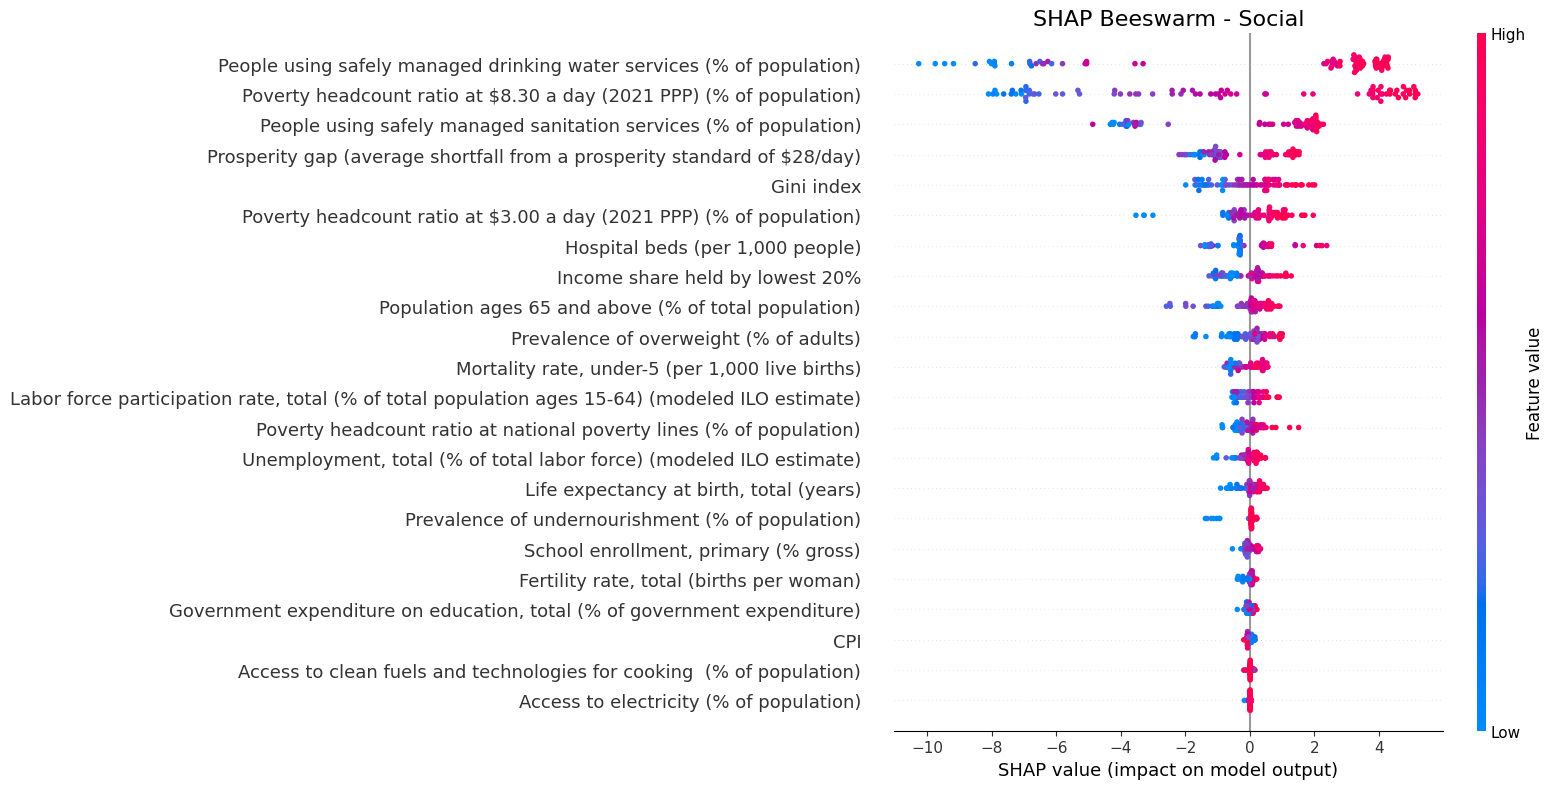

In [24]:
plot_shap(soc_model['shap_values'], soc_model['X_test'], pillar_png='soc', pillar_title='Social')

## <span style="color:#e0bda8">6.3. Governance Pillar </span>

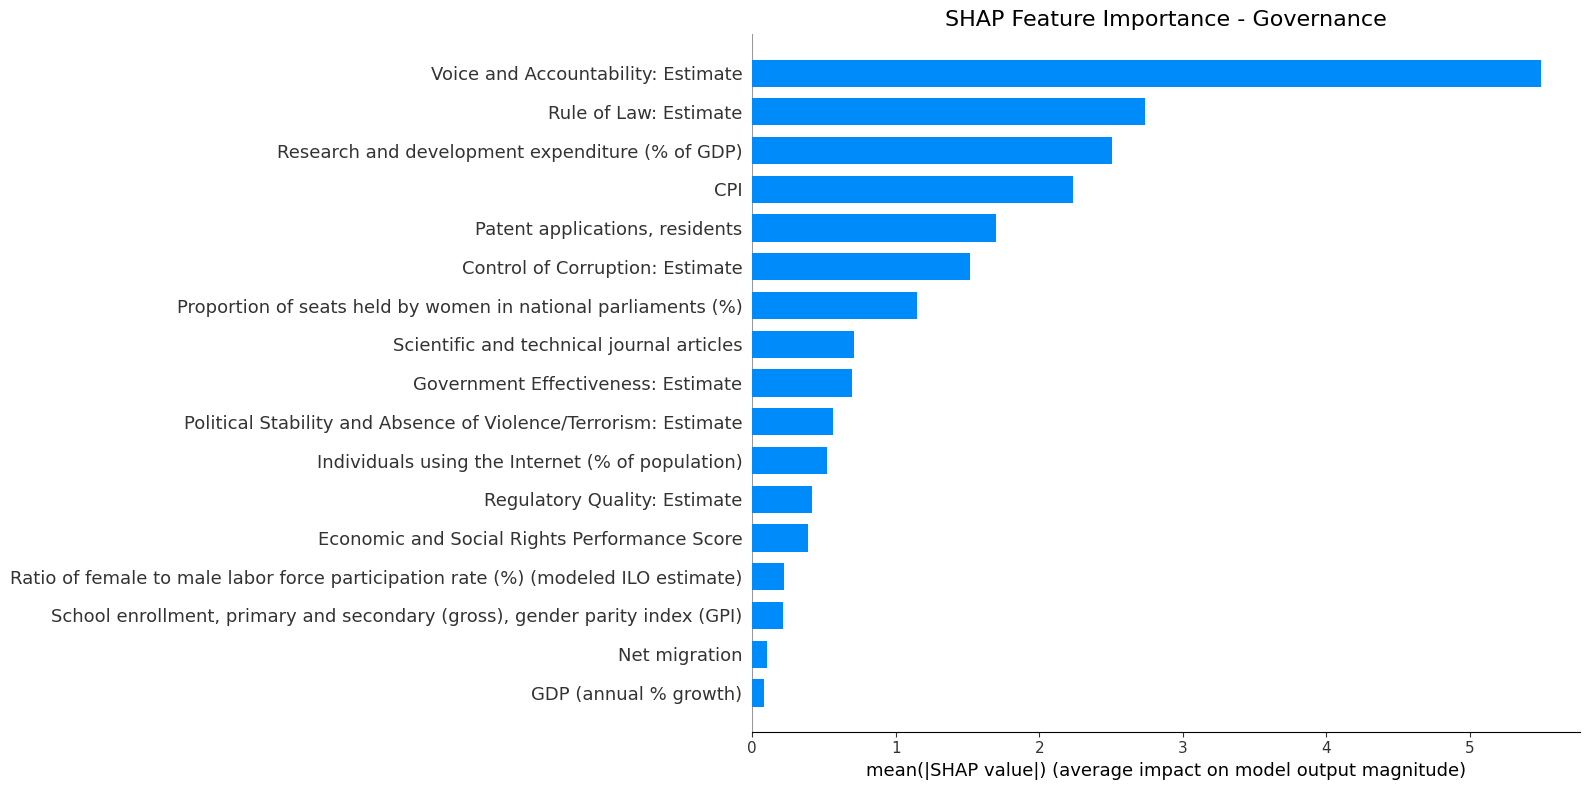

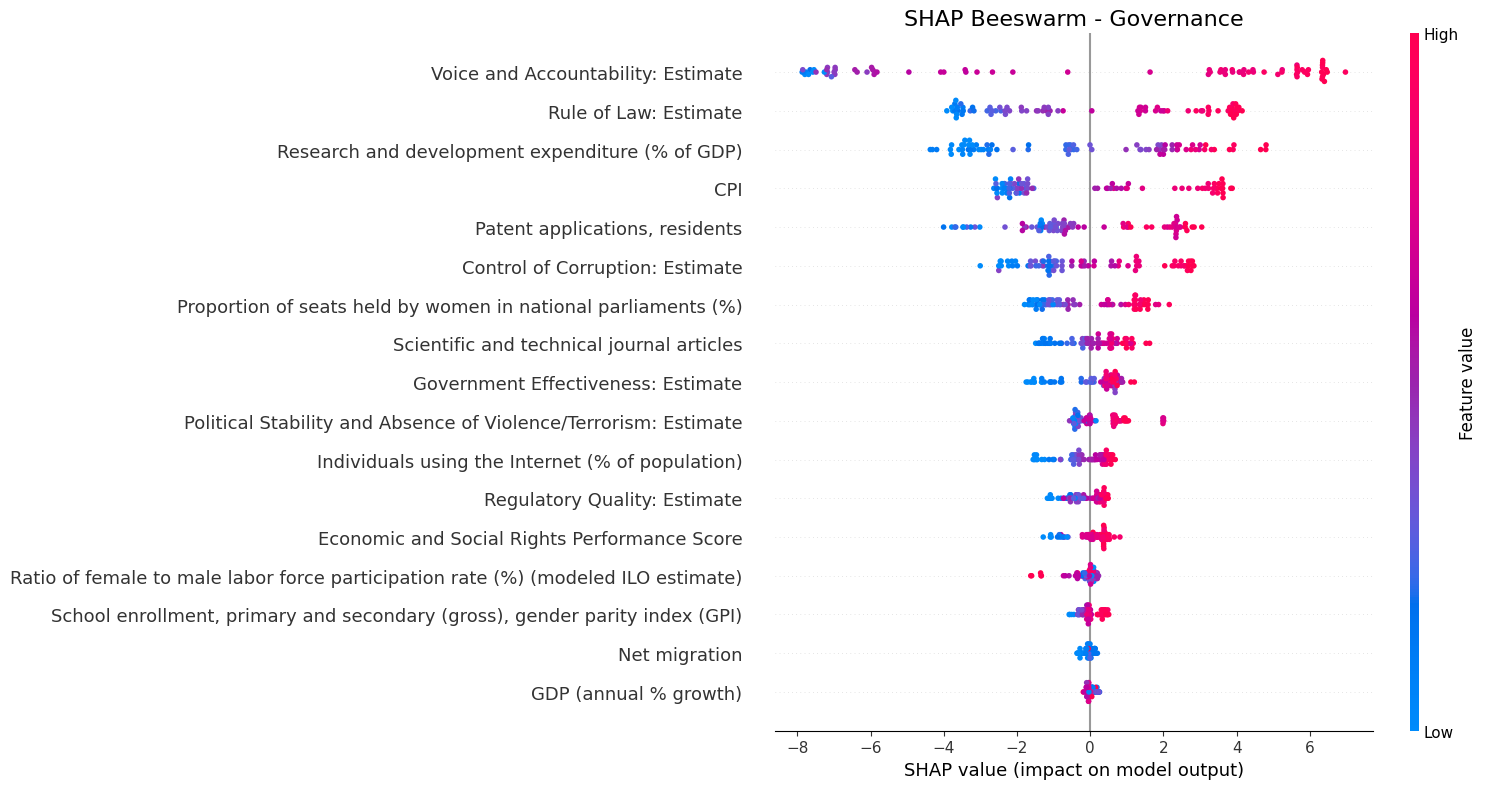

In [25]:
plot_shap(gov_model['shap_values'], gov_model['X_test'], pillar_png='gov', pillar_title='Governance')